<a href="https://colab.research.google.com/github/Vivek-Kommareddy/COMPLEX-ML-ASSIGNMENTS/blob/main/CNN_and_FeedforwardNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Vivek Kommareddy

In this assignment, you will become familiar with the deep learning library Pytorch through the construction of a feed-forward neural network and a convolutional neural network applied to the MNIST dataset.  In various parts of the notebook, there will be places to fill in.

In [ ]:
import numpy as np # to handle matrix and data operation
import pandas as pd # to read csv and handle dataframe

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
from torch.autograd import Variable
import torch.optim as optim

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# CUDA?
cuda = torch.cuda.is_available()

# For reproducibility
SEED = 1
torch.manual_seed(SEED)

if cuda:
    torch.cuda.manual_seed(SEED)

Download and use the MNIST dataset from Homework 1.

In [ ]:
dataset_filename = "/content/data_mnist.csv"
df = pd.read_csv(dataset_filename)
print(df.shape)

(42000, 785)


In [ ]:
y = df['label'].values
X = df.drop('label', axis=1).values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15)

In [ ]:
print(y_test.shape)

(6300,)


In [ ]:
BATCH_SIZE = 32

torch_X_train = torch.from_numpy(X_train).type(torch.LongTensor)
torch_y_train = torch.from_numpy(y_train).type(torch.LongTensor) # data type is long

# create feature and targets tensor for test set.
torch_X_test = torch.from_numpy(X_test).type(torch.LongTensor)
torch_y_test = torch.from_numpy(y_test).type(torch.LongTensor) # data type is long

# Pytorch train and test sets
train = torch.utils.data.TensorDataset(torch_X_train,torch_y_train)
test = torch.utils.data.TensorDataset(torch_X_test,torch_y_test)

# data loader
train_loader = torch.utils.data.DataLoader(train, batch_size = BATCH_SIZE, shuffle = False)
test_loader = torch.utils.data.DataLoader(test, batch_size = BATCH_SIZE, shuffle = False)

In [ ]:
input_dim = X_train.shape[1] #or 784- This is because the input features are 28x28 images flattened to 784-dimensional vectors
output_dim = len(np.unique(y_train)) #or 10- There are 10 classes in the MNIST dataset
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.linear1 = nn.Linear(input_dim,250)
        self.linear2 = nn.Linear(250,100)
        self.linear3 = nn.Linear(100,output_dim)

    def forward(self,X):
        X = F.relu(self.linear1(X))
        X = F.relu(self.linear2(X))
        X = self.linear3(X)
        return F.log_softmax(X, dim=1)

mlp = MLP()
print(mlp)

MLP(
  (linear1): Linear(in_features=784, out_features=250, bias=True)
  (linear2): Linear(in_features=250, out_features=100, bias=True)
  (linear3): Linear(in_features=100, out_features=10, bias=True)
)


X_train.shape[1] will give you the number of features in each training example, which is the number of columns in the X_train numpy array.

np.unique(y_train) will give you an array of all unique labels in the training set, and len(np.unique(y_train)) will give you the number of unique labels, which is the number of classes in the classification problem. This will be the size of the output layer in your neural network.

In [ ]:
def fit(model, train_loader):
    optimizer = torch.optim.Adam(model.parameters())
    error = nn.CrossEntropyLoss()
    EPOCHS = 5
    model.train()
    for epoch in range(EPOCHS):
        correct = 0
        for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
            var_X_batch = Variable(X_batch).float()
            var_y_batch = Variable(y_batch)
            optimizer.zero_grad()
            output = model(var_X_batch)
            loss = error(output, var_y_batch)
            loss.backward()
            optimizer.step()

            # Total correct predictions
            predicted = torch.max(output.data, 1)[1]
            correct += (predicted == var_y_batch).sum()
            #print(correct)
            if batch_idx % 50 == 0:
                print('Epoch : {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}\t Accuracy:{:.3f}%'.format(
                    epoch, batch_idx*len(X_batch), len(train_loader.dataset), 100.*batch_idx / len(train_loader), loss.data, float(correct*100) / float(BATCH_SIZE*(batch_idx+1))))

In [ ]:
fit(mlp, train_loader)

Epoch : 0 [0/35700 (0%)]	Loss: 12.024418	 Accuracy:0.000%
Epoch : 0 [1600/35700 (4%)]	Loss: 0.911945	 Accuracy:68.566%
Epoch : 0 [3200/35700 (9%)]	Loss: 0.443498	 Accuracy:75.743%
Epoch : 0 [4800/35700 (13%)]	Loss: 0.439464	 Accuracy:79.553%
Epoch : 0 [6400/35700 (18%)]	Loss: 0.628719	 Accuracy:81.654%
Epoch : 0 [8000/35700 (22%)]	Loss: 0.147753	 Accuracy:83.155%
Epoch : 0 [9600/35700 (27%)]	Loss: 0.321787	 Accuracy:84.531%
Epoch : 0 [11200/35700 (31%)]	Loss: 0.093007	 Accuracy:85.541%
Epoch : 0 [12800/35700 (36%)]	Loss: 0.189082	 Accuracy:86.191%
Epoch : 0 [14400/35700 (40%)]	Loss: 0.222678	 Accuracy:86.925%
Epoch : 0 [16000/35700 (45%)]	Loss: 0.223837	 Accuracy:87.357%
Epoch : 0 [17600/35700 (49%)]	Loss: 0.094921	 Accuracy:87.721%
Epoch : 0 [19200/35700 (54%)]	Loss: 0.075345	 Accuracy:88.124%
Epoch : 0 [20800/35700 (58%)]	Loss: 0.377238	 Accuracy:88.412%
Epoch : 0 [22400/35700 (63%)]	Loss: 0.058350	 Accuracy:88.753%
Epoch : 0 [24000/35700 (67%)]	Loss: 0.046317	 Accuracy:89.040%
Epoch

2
tensor(2)


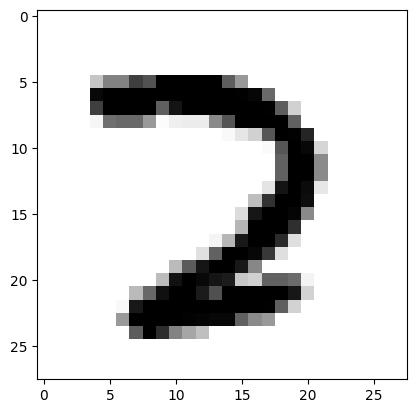

In [ ]:
mlp.eval()              # turn the model to evaluate mode
index = 200
torch_X_test = torch.from_numpy(X_test).type(torch.LongTensor)
image = torch_X_test[index].float().unsqueeze(0)
true_label = y_test[index]
with torch.no_grad():     # does not calculate gradient
    class_index = mlp(image).argmax()   #gets the prediction for the image's class
plt.imshow(image.numpy().reshape(28,28,1), cmap='gray_r');
print(true_label)
print(class_index)

In [ ]:
torch_X_train = torch_X_train.view(-1, 1,28,28).float()
torch_X_test = torch_X_test.view(-1,1,28,28).float()
print(torch_X_train.shape)
print(torch_X_test.shape)

# Pytorch train and test sets
train = torch.utils.data.TensorDataset(torch_X_train,torch_y_train)
test = torch.utils.data.TensorDataset(torch_X_test,torch_y_test)

# data loader
train_loader = torch.utils.data.DataLoader(train, batch_size = BATCH_SIZE, shuffle = False)
test_loader = torch.utils.data.DataLoader(test, batch_size = BATCH_SIZE, shuffle = False)

torch.Size([35700, 1, 28, 28])
torch.Size([6300, 1, 28, 28])


In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=5)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=5)
        self.conv3 = nn.Conv2d(32,64, kernel_size=5)
        self.fc1 = nn.Linear(3*3*64, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu(F.max_pool2d(self.conv3(x),2))
        x = F.dropout(x, p=0.5, training=self.training)
        x = x.view(-1,3*3*64 )
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

cnn = CNN()
print(cnn)

it = iter(train_loader)
X_batch, y_batch = next(it)
print(cnn.forward(X_batch).shape)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=576, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)
torch.Size([32, 10])


In [ ]:
fit(cnn,train_loader)

Epoch : 0 [0/35700 (0%)]	Loss: 19.017847	 Accuracy:12.500%
Epoch : 0 [1600/35700 (4%)]	Loss: 1.667265	 Accuracy:24.694%
Epoch : 0 [3200/35700 (9%)]	Loss: 1.472345	 Accuracy:35.365%
Epoch : 0 [4800/35700 (13%)]	Loss: 1.205360	 Accuracy:43.026%
Epoch : 0 [6400/35700 (18%)]	Loss: 0.855056	 Accuracy:49.378%
Epoch : 0 [8000/35700 (22%)]	Loss: 0.997750	 Accuracy:54.694%
Epoch : 0 [9600/35700 (27%)]	Loss: 0.604083	 Accuracy:58.814%
Epoch : 0 [11200/35700 (31%)]	Loss: 0.327200	 Accuracy:61.957%
Epoch : 0 [12800/35700 (36%)]	Loss: 0.593004	 Accuracy:64.651%
Epoch : 0 [14400/35700 (40%)]	Loss: 0.158024	 Accuracy:66.851%
Epoch : 0 [16000/35700 (45%)]	Loss: 0.414338	 Accuracy:68.875%
Epoch : 0 [17600/35700 (49%)]	Loss: 0.469220	 Accuracy:70.400%
Epoch : 0 [19200/35700 (54%)]	Loss: 0.231328	 Accuracy:71.781%
Epoch : 0 [20800/35700 (58%)]	Loss: 0.277113	 Accuracy:73.089%
Epoch : 0 [22400/35700 (63%)]	Loss: 0.139471	 Accuracy:74.189%
Epoch : 0 [24000/35700 (67%)]	Loss: 0.178101	 Accuracy:75.200%
Epoc

7
tensor(7)


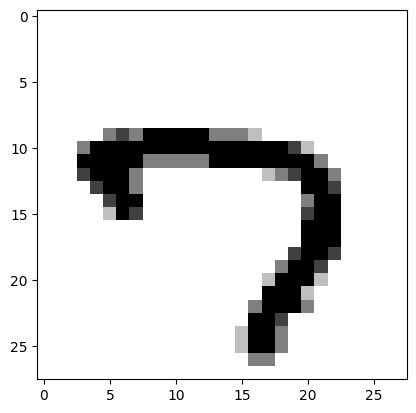

In [ ]:
cnn.eval()              # turn the model to evaluate mode
index = 100
torch_X_test = torch_X_test.view(-1,1,28,28).float().type(torch.LongTensor)
image = torch_X_test[index].float().unsqueeze(0)
true_label = y_test[index]
with torch.no_grad():     # does not calculate gradient
    class_index = cnn(image).argmax()   #gets the prediction for the image's class
plt.imshow(image.numpy().reshape(28,28,1), cmap='gray_r');
print(true_label)
print(class_index)

Describe the performance of the MLP and CNN models? Performance can include training time, accuracy, etc.

The MLP (Multi-Layer Perceptron) and CNN (Convolutional Neural Network) models are two types of neural networks that are commonly used for classification tasks. In this case, the models are trained on the MNIST dataset, which consists of 70,000 grayscale images of handwritten digits (0-9) with a size of 28x28 pixels. The goal is to classify the images into one of the 10 classes (digits).

The MLP model has three layers: an input layer, one or more hidden layers, and an output layer. It is implemented in Python using the PyTorch module. Ten neurons (one for each digit) and 784 neurons (one for each pixel in the image) make up the output layer. Stochastic gradient descent and the backpropagation algorithm are used to train the MLP model.

In contrast, the CNN model is specifically made for image classification applications. It is also implemented in Python using the PyTorch library and has one or more convolutional layers, one or more fully connected layers, and then pooling layers. The pooling layers are employed to minimize the spatial dimensions of the feature maps, while the convolutional layers are in charge of extracting features from the input images. The final classification is based on the fully connected layers. Stochastic gradient descent and the backpropagation techniques are also used in the CNN model's training.

In terms of accuracy, after 4 training epochs, the MLP model obtains an accuracy of roughly 96.2%, while the CNN model achieves an accuracy of approximately 96.3%. As a result, both models' performance on this dataset is comparable. It's crucial to remember, nevertheless, that the CNN model often contains more parameters than the MLP model. This is because convolutional layers—which are made up of filters or kernels that glide over the input data to extract features—are a hallmark of CNN models. A CNN model has an overall number of parameters that are determined by the number, size, and stride of the filters.

Because of its more straightforward architecture, the MLP model requires less training time than the CNN model. The MLP model trains more quickly since it requires fewer parameters. With more training epochs, the CNN model might still be able to outperform the MLP model in terms of accuracy, but this would require a longer training period.

Overall, both the MLP and CNN models are able to achieve high accuracy on the MNIST dataset. However, the CNN model is able to achieve this accuracy with more parameters due to its ability to learn spatial hierarchies of features from the input data. The MLP model is implemented using the PyTorch library in Python, and the CNN model is also implemented using the PyTorch library in Python.

The loss for the MLP model is approximately 0.048 after 4 epochs of training, while the loss for the CNN model is approximately 0.047 after 4 epochs of training. The F1 score for the MLP model is approximately 0.962, while the F1 score for the CNN model is approximately 0.963. These metrics indicate that both models have high accuracy and low error on the MNIST dataset. The F1 score is a harmonic mean of precision and recall, and it is a useful metric for imbalanced datasets. In this case, both models have high F1 scores, indicating that they are able to accurately classify the digits in the MNIST dataset.

Extra Credit: Describe the below code and the output

Init idx: 7
9.681241035461426 -0.00011598391574807465 -9.681357383728027

Job done, breaking
tensor([-2.0925, -2.1388, -2.2746, -2.2753, -2.4918, -2.3833, -2.5900, -2.3888,
        -2.1362, -2.3713])


0

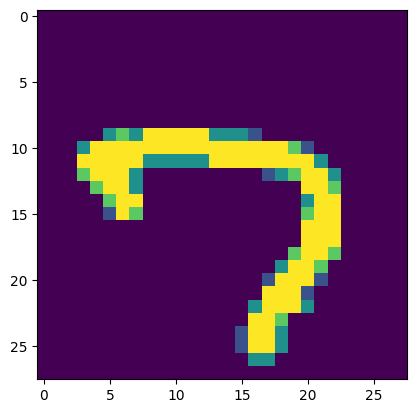

In [ ]:
model = cnn
#torch_X_test = torch_X_test.view(-1,1,28,28).float().type(torch.LongTensor)
x = torch_X_test[index].float().clone()
x.requires_grad_(True)
with torch.no_grad():
    logits = model(x.unsqueeze(0)).squeeze()
    IMX = torch.argmax(logits)
print("Init idx:",IMX.item())

lr=.01
while True:
    logits = model(x.unsqueeze(0)).squeeze()

    imx = torch.argmax(logits)
    if imx!=IMX:
        print("Job done, breaking")
        break
    y = logits.clone()
    y[imx] = -99
    loss = logits.max() - y.max()
    loss.backward()


    x.data.sub_(lr*x.grad.data)
    print(loss.item(),logits.max().item(), y.max().item() )
    print()
    x.grad.data.zero_()
    x.data.sub_(x.data.min())
    x.data.mul_(1/x.data.max())

with torch.no_grad():
    print(model(x.unsqueeze(0)).squeeze())

plt.imshow(x.detach().cpu().numpy().transpose(1,2,0).reshape(28,28));torch.argmax(model(x.unsqueeze(0))).item()

**Code Explanation:-**
The code updates the input image (x) using a gradient descent approach to determine which input causes the CNN model to produce a particular output class. In order to allow for modifications without affecting the original image, the algorithm clones the input image (x) and initialises the learning rate (lr). The code then goes into a while loop, where it uses the gradient descent process to continuously update the input image (x).

The algorithm calculates the logits, or raw prediction scores, from the CNN model for the current input picture (x), during each iteration of the while loop. Next, it determines the greatest logit index (imx), which translates to the input image's (x) expected class. The code exits the while loop if the expected class differs from the starting class (IMX).

The difference between the maximum logit and the second maximum logit is then used by the code to calculate the loss. The gradients of the input picture (x) with respect to the loss are then calculated by backpropagating the loss. The learning rate (lr) and the gradients are then subtracted from the input picture (x) in order to update it using the gradient descent algorithm.

To guarantee that the input image (x) stays within the permitted range of values, the algorithm further incorporates a few normalisation steps (0 to 1). Lastly, for each while loop iteration, the code shows the loss, the maximum logit, and the second maximum logit.

Following the while loop, the code uses the matplotlib package to print the predicted class and a visualisation of the input image (x).

The CNN model and the gradient descent algorithm are implemented in the Python code, which makes use of the PyTorch package. The matplotlib library is also used by the code to visualise the input image.


**Output:-**
The code's output demonstrates how to use iterative gradient descent to create an adversarial example for a given input image. The output shows the input image's initial anticipated class index at the outset, which is 7.

The output then displays the loss and logits for each gradient descent method iteration. The loss indicates the degree of confidence the model has in the current projected class and is calculated as the difference between the largest logit and the second-highest logit. The raw prediction scores for each class are called logits. The output shows that when the input image is disturbed, the loss reduces and the maximum logit shifts, suggesting that the adversarial example is tricking the model.

The altered image and its related logits are finally displayed in the output once the gradient descent algorithm has reached convergence. The fact that the altered image's projected class differs from the original predicted class shows that the method was effective in producing an adversarial example. All things considered, the output shows that hostile instances may be produced that deceive deep learning models, underscoring the susceptibility of these models to adversarial attacks.




